<a href="https://colab.research.google.com/github/andresdelyukon/forecasting_campa-as/blob/main/Forecasting_campa%C3%B1as.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python -m pip install prophet


In [ ]:
import pandas as pd
from prophet import Prophet

In [ ]:
# # # # Conectar a Drive
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

# Análisis histórico por campaña


In [ ]:
#all media
worksheet = gc.open_by_key("114qrqgEosT7FSLDpA210ksnuBHVjUUlpdfKArm-6Nq8").sheet1
rows = worksheet.get_all_values()
df_all_media = pd.DataFrame.from_records(rows)
df_all_media = pd.DataFrame.from_records(rows[1:], columns=rows[0])



In [ ]:
todos_flotan = ["clicks", "spend", "impressions", "CPC", "CPM", "CTR", "Transacciones", "CPA", "Revenue con IVA", "ROAS"]

In [ ]:
array_fesa = ["Clicks", "Impresiones", "Spend"]

In [ ]:
#cambia el array en base a las columnas del documento que tengas
for globo in array_fesa:
  df_all_media[globo] = df_all_media[globo].astype(float)

In [ ]:
#campañas de innova
import pandas as pd


campanas = ["aw_innova_ecomm_do_sem_brand_terms_ao",
            "fb_innova_ecomm_do_asc_ao_view",
            "fb_innova_ecomm_think_auct_daba_view_always-on",
            "fb_innova_ecomm_do_auct_dpa_cart_always-on",
            "fb_innova_ecomm_do_auct_dpa_view_always-on"
            "fb_innova_ecomm_do_auct_dpa_legends-on",
            "fb_innova_ecomm_think_auct_daba_compra_always-on",
            "aw_innova_ecomm_do_pmax_all_ao",
            "aw_innova_ecomm_do_pmax_ac_ao_v3",
            "aw_innova_ecomm_do_pla_cat_ao_calzado_v2",
            "fb_innova_ecomm_do_asc_ao_purchase",
            "fb_innova_ecomm_do_auct_conv_lal_registros_legends_always-on",
            "aw_innova_ecomm_do_pmax_cat_ao_calzado_v2",
            "ma_innova_do_sem_brand-terms_ao",
            "aw_innova_ecomm_do_pla_all_ao_hp_nobt",
            "aw_innova_ecomm_do_pla_cat_ao_villanos_v2",
            "aw_innova_ecomm_do_pla_cat_ao_calzado_hp_nobt_v2",
            "fb_innova_ecomm_do_asc_ao_cart",
            "aw_innova_ecomm_do_pmax_reengagement_v3",
            "aw_innova_ecomm_do_sem_brand_terms_geo",
            "aw_innova_ecomm_do_pmax_cat_ao_villanos_v2",
            "aw_innova_ecomm_do_pla_cat_ao_villanos_hp_nobt_v2",
            "aw_innova_ecomm_do_sem_brand_cat_ao",
            "aw_innova_ecomm_do_pla_all_ao",
            "aw_innova_ecomm_think_dsa_ao",
            "aw_innova_ecomm_think_sem_cpt",
            "aw_innova_ecomm_think_sem_gen_cat_ao",
            "aw_innova_ecomm_think_demand-gen_ao_v2"
            ]

In [ ]:
#campañas de fesa
import pandas as pd


campanas = ["fb_fesa_ecomm_do_auct_daba_view_aon","fb_fesa_brn_see_auct_awareness_aon","fb_fesa_ecomm_do_auct_asc_ao_v2","fb_fesa_ecomm_do_auct_dpa_ao_viewcontent","fb_fesa_ecomm_do_auct_dpa_ao_addtocart","fb_fesa_ecomm_do_auct_daba_purchase_aon","fb_fesa_brn_see_auct_reach_thruplay_podcast","aw_fesa_call_do_sem_brand_terms_general","aw_fesa_ecomm_do_sem_gen_medicamentos","aw_fesa_call_do_sem_gen_competidores","aw_fesa_ecomm_do_sem_brand_terms_geo","aw_fesa_ecomm_do_uac_android_install","aw_fesa_ecomm_do_pmax_estandar_ao","aw_fesa_ecomm_do_sem_brand_terms_general_v2","aw_fesa_ecomm_do_sem_gen_general_offline","aw_fesa_ecomm_do_uac_android_install_purchase","aw_fesa_ecomm_do_sem_gen_general_v2","aw_fesa_brn_think_uac_installs_IOS","fb_fesa_ecomm_do_auct_asc_ao_v3","fb_fesa_ecomm_do_auct_daba_view_aon_v2","fb_fesa_ecomm_do_auct_daba_purchase_aon_v2","fb_fesa_ecomm_do_auct_dpa_ao_addtocart_v2","fb_fesa_ecomm_do_auct_dpa_ao_viewcontent_v2","fb_fesa_whatsapp_think_auct_mensajes","aw_fesa_ecomm_do_sem_brand_terms_general_v2 bidxdia","fb_fesa_ecomm_do_auct_conv_web_aon_v2","aw_fesa_ecomm_think_dsa_gral","fb_fesa_call_do_auct_shopping","fb_fesa_ecomm_think_auct_traffic_online_app_v2","fb_fesa_ecomm_think_auct_traffic_categorias","fb_fesa_brn_see_auct_awareness_store","aw_fesa_ecomm_do_sem_gen_categorias","aw_fesa_ecomm_do_sem_gen_skincare","fb_fesa_ecomm_do_auct_daba_addtocart_aon","aw_fesa_ecomm_do_pmax_feed_ao","aw_fesa_ecomm_do_pmax_prod_menor_mil_ao","fb_fesa_ecomm_do_auct_dpa_viewcontent_v1_aon","aw_fesa_brn_think_uac_installs_android","fb_fesa_app_think_auct_asc_installs_android","fb_fesa_ecomm_think_auct_asc_app_installs_IOS","aw_fesa_ecomm_think_gdn_awareness_endocrinologia","aw_fesa_ecomm_think_gdn_awareness_neuro","aw_fesa_ecomm_think_demand-gen_neuro","aw_fesa_ecomm_think_demand-gen_endocrinologia","aw_fesa_ecomm_think_gdn_awareness_oncologia","aw_fesa_ecomm_think_demand-gen_oncologia","fb_fesa_ecomm_do_auct_daba_view_aon_v3","fb_fesa_ecomm_do_auct_dpa_ao_addtocart_v3","aw_fesa_ecomm_do_uac_view-item_android","fb_fesa_brn_see_rf_reach_abril2024","fb_fesa_ecomm_do_auct_conv_web_aon_addtocart","fb_fesa_brn_see_rf_reach_abril2024_v2","fb_fesa_brn_see_auct_reach_ofertascalientes","fb_fesa_ecomm_do_auct_dpa_unificada_aon","fb_fesa_brn_see_auct_reach_venta-relampago","fb_fesa_ecomm_do_auct_daba_purchase_aon_v3","fb_fesa_brn_see_auct_reach_ofertas-padrisimas","aw_fesa_brn_think_demandgen_traffic","fb_fesa_brn_see_rf_reach_junio2024","fb_fesa_app_do_auct_addtocart_android","fb_fesa_whatsapp_think_auct_mensajes_rmk","fb_fesa_brn_see_rf_reach_junio2024_v2","fb_fesa_brn_see_auct_reach_verano-sin-preocupaciones","fb_fesa_brn_see_auct_reach_alta-especialidad","fb_fesa_ecomm_do_auct_asc_aon_2024","aw_fesa_ecomm_do_sem_gen_general_ao","aw_fesa_whatsapp_do_pmax_feed_ao #2","aw_fesa_whatsapp_do_pmax_feed_ao","aw_fesa_whatsapp_do_pmax_estandar_ao","aw_fesa_brn_see_yt_video-views_aon","aw_fesa_ecomm_do_pla_general","aw_fesa_whatsapp_leads_do_sem_gen_general","aw_fesa_call_do_pmax_estandar_ao","aw_fesa_ecomm_do_pmax_estandar_app-web","fb_fesa_brn_think_auct_promoted-post_engagement","fb_fesa_contact-center_do_auct_engagement_whatsapp","aw_fesa_ecomm_do_pmax_estandar_aon","aw_fesa_ecomm_do_uac_cart_android","fb_fesa_contact-center_do_auct_engagement_whatsapp_ao","fb_fesa_brn_think_auct_promoted-post_engagement_ao","fb_fesa_brn_think_auct_fanpage_meta","fb_fesa_brn_think_auct_alcance_ig","fb_fesa_ecomm_asc_sales_ao","fb_fesa_ecomm_asc_viewcontent_ao","fb_fesa_contact-center_do_auct_engagement_whatsapp_aon","aw_fesa_brn_think_demand_gen_viewcontent_aon","fb_fesa_brn_think_auct_alcance_adrecall_birdman","aw_fesa_brn_think_demand_gen_viewcontent_ao","fb_fesa_ecomm_asc_rmk_ao"]


In [ ]:
#ya están agrupadas, más bien quiero un filtro
#necesito comparar la fila del df vs un array en la columna df[campaign.name]. Si la campaña está filtrala.
boolean_mask = df_all_media['campaign.name'].isin(campanas)


In [ ]:
filtered_df = df_all_media[boolean_mask]
print(filtered_df)

                                  campaign.name                     Objetivo  \
0           fb_fesa_ecomm_do_auct_daba_view_aon         Tráfico al sitio web   
1            fb_fesa_brn_see_auct_awareness_aon              Alcance / Reach   
2               fb_fesa_ecomm_do_auct_asc_ao_v2               Venta en sitio   
3      fb_fesa_ecomm_do_auct_dpa_ao_viewcontent               Venta en sitio   
4        fb_fesa_ecomm_do_auct_dpa_ao_addtocart               Venta en sitio   
...                                         ...                          ...   
12878    aw_fesa_brn_think_uac_installs_android           Instalación de APP   
12879       aw_fesa_ecomm_do_sem_gen_general_ao               Venta en sitio   
12880              aw_fesa_ecomm_do_pla_general               Venta en sitio   
12881        aw_fesa_ecomm_do_pmax_estandar_aon               Venta en sitio   
12882         aw_fesa_ecomm_do_uac_cart_android  Instalación + Evento en APP   

                       Objetivo por med

# Comparativa optimización de objetivos MMM vs distribución presupuestaria actual


In [ ]:
df_presupuesto = df_all_media.groupby("Objetivo por medio")['Spend'].agg(['sum'])

In [ ]:
df_presupuesto['presupuesto en porcentaje actual'] = (
    df_presupuesto['sum'] / df_presupuesto['sum'].sum() * 100
)

In [ ]:
df_presupuesto_actual = df_presupuesto.sort_values('presupuesto en porcentaje actual', ascending=False)

In [ ]:
#pasa sum a números normales
df_presupuesto_actual['sum'] = df_presupuesto_actual['sum'].astype(float)

In [ ]:
df_presupuesto_actual.head(25)

,sum,presupuesto en porcentaje actual
Objetivo por medio,,
google Venta en sitio,1.373350e+07,52.492482
google llamadas,3.444947e+06,13.167349
google Instalación + Evento en APP,3.006714e+06,11.492325
google Instalación de APP,1.936818e+06,7.402946
facebook Campañas de WhatsApp,1.236870e+06,4.727590
google Tráfico/Consideración,6.348226e+05,2.426432
facebook Alcance / Reach,4.527161e+05,1.730381
facebook Venta en sitio,4.472840e+05,1.709618
facebook Campañas Llamadas,2.718070e+05,1.038906


In [ ]:
worksheet = gc.open_by_key("1WvlbVZJWePjZQZ5g3eszzLiqmUAfrJmu-b3ayu8n1vo").sheet1
rows = worksheet.get_all_values()
presupuesto_optimizado = pd.DataFrame.from_records(rows)
presupuesto_optimizado = pd.DataFrame.from_records(rows[1:], columns=rows[0])


In [ ]:
presupuesto_optimizado['presupuesto recomendado por modelo'] = presupuesto_optimizado['presupuesto recomendado por modelo'].astype(float)

In [ ]:
presupuesto_optimizado.head()

,Objetivo,presupuesto recomendado por modelo
0,PMAX,27.70
1,DABA,19.20
2,DPA,16.70
3,ASC,12.10
4,BRAND_TERMS,7.93


In [ ]:
presupuestos_unidos = pd.merge(
    df_presupuesto_actual,
    presupuesto_optimizado,
    on = 'Objetivo',
    how = 'left'
)

# Presupuesto actual vs presupuesto recomendado por el modelo


<Axes: xlabel='Objetivo'>

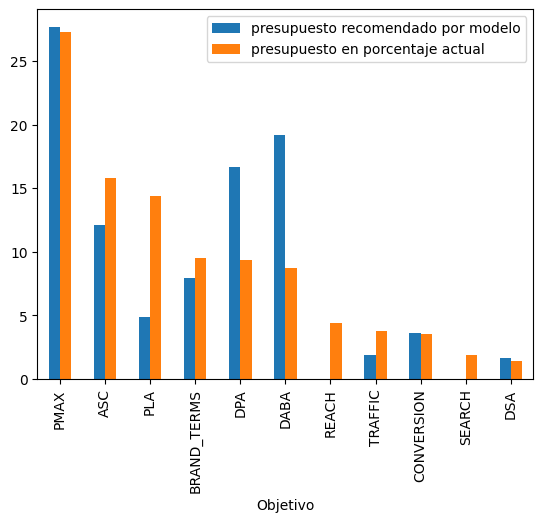

In [ ]:
#podemos ver que la recomendación de aumentar a PMAX ya no va pues ya la ejecutaron. Ya se pasaron en ASC y PLA. PLA no le puedo bajar porque ahorita mismo hay promociones
#los accionables de un MMM es usarlo para reasignar presupuesto en un objetivo de medios particular. Creo que podemos proponerles lo siguiente; el MMM sirve para asignar presupuestos en un acuerto
#como mínima cantidad de tiempo medible.
#entonces lo único que se me ocurre es; el cambio no es de aquí a una semana, si no de aquí a un cuarto.
#es que no hay una compaginación entre el mROAs y el ROAS de atribución que están haciendo.
#Tiene sentido que se le baje porque ASC es como el PMAX de facebook. A PLA también se le sugiere bajar pero creo que la tendencia del objetivo es lo que importa.
#El media mix no nos dice a, tiene bajo ROAS cierto objetivo, nos dice que ya no tiene tanto espacio de crecimiento. Por ejemplo PMAx ya llegó a donde debía.
#Brand terms no lo podemos tocar, reach no lo modelé. Traffic carece de sentido. Facebook conversion ya llegó a donde debía llegar. Search no lo medí
#Básicamente hay 5 candidatos. ASC quitarle. PLA quitarle mucho. DPA aumentar el doble. DABA aumentar el doble. DPA me dijeron que no tenía sentido porque remarketing ya estaba topado
#queda aumentarle a DABA. ¿en qué campañas? ¿crear alguna nueva?
#bajarle a PLA. Lo ideal sería a total objetivo pero weno.
#aumentarle a DABA nos da proospección de nuevos clientes que pueden alimentar DPA.
#entonces podemos empezar de a poco. Una campaña de PLA a la que le baje lo que le voy a subir a alguna de DABA.
#haz el análisis para la peor campaña de PLA que siga existiendo


presupuestos_unidos.plot(
    x='Objetivo',
    y=['presupuesto recomendado por modelo', 'presupuesto en porcentaje actual'],
    kind='bar'
)

# Desempeño campaña por métrica y rango temporal


In [ ]:
#necesito una función que me permita desglosar el promedio de una columna dada en un rango de tiempo especificado. agrupada por campaña
import pandas as pd
import numpy as np

def analizar_campanas(df, fecha_inicio, fecha_fin, metrica='ROAS', ascendente=False):

    # Copiamos para no modificar original
    df = df.copy()

    # Aseguramos formato fecha
    df['date'] = pd.to_datetime(df['date'])

    # Filtrar periodo
    df = df[(df['date'] >= fecha_inicio) & (df['date'] <= fecha_fin)]

    # Agrupar por campaña
    agg = df.groupby('campaign.name').agg({
        'clicks': 'sum',
        'spend': 'sum',
        'impressions': 'sum',
        'Transacciones': 'sum',
        'Revenue con IVA': 'sum'
    }).reset_index()

    # Recalcular métricas correctamente
    agg['CTR'] = agg['clicks'] / agg['impressions']
    agg['CPC'] = agg['spend'] / agg['clicks']
    agg['CPM'] = (agg['spend'] / agg['impressions']) * 1000
    agg['CPA'] = agg['spend'] / agg['Transacciones']
    agg['ROAS'] = agg['Revenue con IVA'] / agg['spend']

    # Reemplazar infinitos
    agg.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Ordenar por métrica seleccionada
    agg = agg.sort_values(by=metrica, ascending=ascendente)

    return agg

# Ranking general de campañas

In [ ]:
#creo que con esta puedo rankear a las campañas. PLA es la que mejor le fue de las normales
resultado = analizar_campanas(
    df_all_media,
    fecha_inicio='2025-01-01',
    fecha_fin='2026-03-10',
    metrica='ROAS'
)

resultado.head(28)

,campaign.name,clicks,spend,impressions,Transacciones,Revenue con IVA,CTR,CPC,CPM,CPA,ROAS
35,aw_innova_ecomm_do_sem_brand_terms_ao,7783031.0,6.190370e+06,19258879.0,160952.0,2.824250e+08,0.404127,0.795368,321.429429,38.460973,45.623285
95,fb_innova_ecomm_think_auct_daba_compra_always-...,4182.0,2.620520e+03,52352.0,28.0,6.145366e+04,0.079882,0.626619,50.055776,93.590000,23.450941
94,fb_innova_ecomm_think_auct_daba_compra_always-...,4631.0,2.619060e+03,55793.0,43.0,5.749980e+04,0.083003,0.565550,46.942448,60.908372,21.954365
16,aw_innova_ecomm_do_pla_vendors_asics_ao,88582.0,7.485145e+04,4285660.0,834.0,1.357882e+06,0.020669,0.844996,17.465560,89.749940,18.141025
88,fb_innova_ecomm_think_auct_daba_compra_always-...,31645.0,1.744141e+04,392573.0,202.0,3.088668e+05,0.080609,0.551158,44.428450,86.343614,17.708818
87,fb_innova_ecomm_think_auct_daba_compra_always-...,172845.0,8.735661e+04,2407324.0,849.0,1.228721e+06,0.071800,0.505404,36.287849,102.893534,14.065573
20,aw_innova_ecomm_do_pla_vendors_ua_ao_hp_nobt_v2,24595.0,6.614031e+04,1188967.0,377.0,7.895681e+05,0.020686,2.689177,55.628382,175.438488,11.937775
93,fb_innova_ecomm_think_auct_daba_compra_always-...,66945.0,4.715697e+04,1119446.0,384.0,5.454833e+05,0.059802,0.704414,42.125274,122.804609,11.567396
99,fb_innova_ecomm_think_auct_daba_compra_always-...,11285.0,1.135627e+04,219453.0,76.0,1.230877e+05,0.051423,1.006315,51.748074,149.424605,10.838744
66,fb_innova_ecomm_do_asc_ao_purchase,8028776.0,4.721079e+06,141046264.0,32217.0,4.958557e+07,0.056923,0.588020,33.471847,146.539993,10.503017


In [ ]:
#Ranking por objetivo de campañas
resultado[resultado["campaign.name"].str.contains("_daba_", na=False)]

,campaign.name,clicks,spend,impressions,Transacciones,Revenue con IVA,CTR,CPC,CPM,CPA,ROAS
95,fb_innova_ecomm_think_auct_daba_compra_always-...,4182.0,2.620520e+03,52352.0,28.0,61453.66,0.079882,0.626619,50.055776,93.590000,23.450941
94,fb_innova_ecomm_think_auct_daba_compra_always-...,4631.0,2.619060e+03,55793.0,43.0,57499.80,0.083003,0.565550,46.942448,60.908372,21.954365
88,fb_innova_ecomm_think_auct_daba_compra_always-...,31645.0,1.744141e+04,392573.0,202.0,308866.76,0.080609,0.551158,44.428450,86.343614,17.708818
87,fb_innova_ecomm_think_auct_daba_compra_always-...,172845.0,8.735661e+04,2407324.0,849.0,1228720.78,0.071800,0.505404,36.287849,102.893534,14.065573
93,fb_innova_ecomm_think_auct_daba_compra_always-...,66945.0,4.715697e+04,1119446.0,384.0,545483.35,0.059802,0.704414,42.125274,122.804609,11.567396
99,fb_innova_ecomm_think_auct_daba_compra_always-...,11285.0,1.135627e+04,219453.0,76.0,123087.70,0.051423,1.006315,51.748074,149.424605,10.838744
86,fb_innova_ecomm_think_auct_daba_compra_always-...,218413.0,1.701800e+05,3924493.0,1044.0,1674328.12,0.055654,0.779166,43.363561,163.007653,9.838572
92,fb_innova_ecomm_think_auct_daba_compra_always-...,76001.0,5.242663e+04,1295674.0,374.0,493974.67,0.058658,0.689815,40.462825,140.178155,9.422209
91,fb_innova_ecomm_think_auct_daba_compra_always-...,175812.0,1.361438e+05,3087168.0,787.0,1261556.52,0.056949,0.774372,44.099913,172.990902,9.266350
97,fb_innova_ecomm_think_auct_daba_compra_always-...,8877.0,8.743820e+03,177855.0,46.0,79757.50,0.049911,0.984997,49.162632,190.083043,9.121585


In [ ]:
#aquí hay que poner la serie temporal de la campaña en un periodo temporal
#función que me permita saber si la campaña es continua en un rango de tiempo y me regrese un gráfico temporal de su inversión
def analizar_continuidad_campana_revenue(df, campaign_name, fecha_inicio, fecha_fin):

    import pandas as pd
    import matplotlib.pyplot as plt

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    fecha_inicio = pd.to_datetime(fecha_inicio)
    fecha_fin = pd.to_datetime(fecha_fin)

    # Filtrar campaña y periodo
    df_camp = df[
        (df['campaign.name'] == campaign_name) &
        (df['date'] >= fecha_inicio) &
        (df['date'] <= fecha_fin)
    ]

    # Crear rango completo de fechas
    rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

    fechas_existentes = df_camp['date'].dt.normalize().unique()

    fechas_faltantes = sorted(set(rango_completo) - set(fechas_existentes))

    es_continua = len(fechas_faltantes) == 0

    # Agrupar inversión por día (por si hay varias filas por fecha)
    df_plot = df_camp.groupby('date')['Revenue con IVA'].sum().reset_index()

    # Gráfico
    plt.figure()
    plt.plot(df_plot['date'], df_plot['Revenue con IVA'])
    plt.xlabel("Fecha")
    plt.ylabel("Revenue")
    plt.title(f"revenue diaria - {campaign_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return {
        "continua": es_continua,
        "dias_faltantes": fechas_faltantes,
        "dias_con_data": len(fechas_existentes),
        "dias_esperados": len(rango_completo)
    }

# Serie temporal en el tiempo


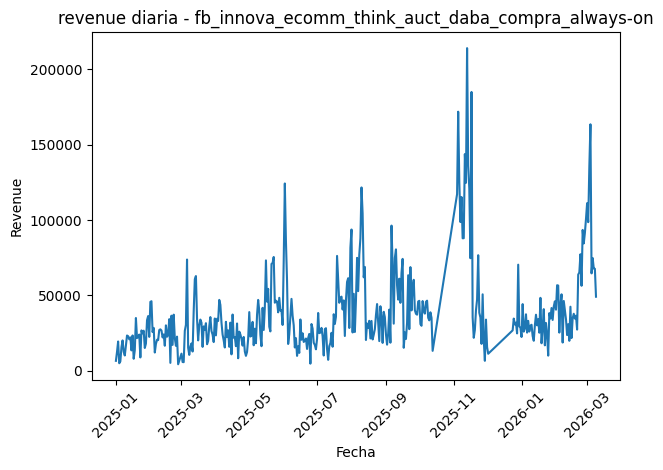

{'continua': False,
 'dias_faltantes': [Timestamp('2025-02-27 00:00:00'),
  Timestamp('2025-02-28 00:00:00'),
  Timestamp('2025-10-14 00:00:00'),
  Timestamp('2025-10-15 00:00:00'),
  Timestamp('2025-10-16 00:00:00'),
  Timestamp('2025-10-17 00:00:00'),
  Timestamp('2025-10-18 00:00:00'),
  Timestamp('2025-10-19 00:00:00'),
  Timestamp('2025-10-20 00:00:00'),
  Timestamp('2025-10-21 00:00:00'),
  Timestamp('2025-10-22 00:00:00'),
  Timestamp('2025-10-23 00:00:00'),
  Timestamp('2025-10-24 00:00:00'),
  Timestamp('2025-10-25 00:00:00'),
  Timestamp('2025-10-26 00:00:00'),
  Timestamp('2025-10-27 00:00:00'),
  Timestamp('2025-10-28 00:00:00'),
  Timestamp('2025-10-29 00:00:00'),
  Timestamp('2025-10-30 00:00:00'),
  Timestamp('2025-10-31 00:00:00'),
  Timestamp('2025-11-01 00:00:00'),
  Timestamp('2025-11-02 00:00:00'),
  Timestamp('2025-11-03 00:00:00'),
  Timestamp('2025-12-03 00:00:00'),
  Timestamp('2025-12-04 00:00:00'),
  Timestamp('2025-12-05 00:00:00'),
  Timestamp('2025-12-06 00

In [ ]:
resultado = analizar_continuidad_campana_revenue(
    df_all_media,
    campaign_name="fb_innova_ecomm_think_auct_daba_compra_always-on",
    fecha_inicio="2025-01-01",
    fecha_fin="2026-03-09"
)

resultado

# Promedio histórico

In [ ]:
def promedio_campana(df, nombre_campana, fecha_inicio, fecha_fin):

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    df_filtrado = df[
        (df['campaign.name'] == nombre_campana) &
        (df['date'] >= fecha_inicio) &
        (df['date'] <= fecha_fin)
    ]

    promedios = df_filtrado[['spend', 'Revenue con IVA', 'ROAS']].mean()

    return promedios

In [ ]:
promedio_campana(df_all_media, "aw_innova_ecomm_do_pla_cat_ao_villanos_hp_nobt_v2", "2026-01-01", "2026-03-09")

,0
spend,690.461127
Revenue con IVA,3630.036761
ROAS,5.692958


In [ ]:
#estaría bueno graficar el ROAS de la campaña por mes y en realidad así detectamos más fácil los outliers
def analizar_roas_mensual(df, campaign_name, fecha_inicio, fecha_fin):

    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    fecha_inicio = pd.to_datetime(fecha_inicio)
    fecha_fin = pd.to_datetime(fecha_fin)

    # Filtrar campaña y periodo
    df_camp = df[
        (df['campaign.name'] == campaign_name) &
        (df['date'] >= fecha_inicio) &
        (df['date'] <= fecha_fin)
    ]

    # Crear columna de mes
    df_camp['mes'] = df_camp['date'].dt.to_period('M')

    # Agrupar por mes
    df_mes = df_camp.groupby('mes').agg({
        'Revenue con IVA': 'sum',
        'spend': 'sum'   # spend
    }).reset_index()

    # Calcular ROAS
    df_mes['ROAS'] = np.where(
        df_mes['spend'] > 0,
        df_mes['Revenue con IVA'] / df_mes['spend'],
        np.nan
    )

    # Convertir mes a timestamp para graficar
    df_mes['mes'] = df_mes['mes'].dt.to_timestamp()

    # Gráfica
    plt.figure()
    plt.plot(df_mes['mes'], df_mes['ROAS'], marker='o')
    plt.xlabel("Mes")
    plt.ylabel("ROAS")
    plt.title(f"ROAS mensual - {campaign_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df_mes


/tmp/ipykernel_201/3984952052.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_camp['mes'] = df_camp['date'].dt.to_period('M')


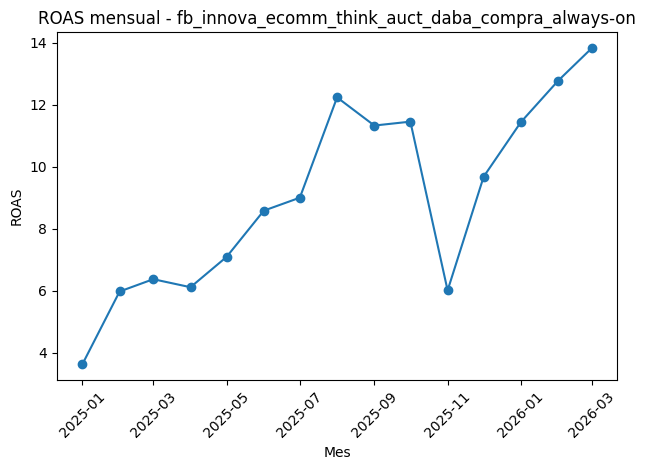

In [ ]:
#creo que esta es la más fácil de evaluar y me permite observar si históricamente la campaña ha ido creciendo
roas_analizable = analizar_roas_mensual(
    df_all_media,
    campaign_name="fb_innova_ecomm_think_auct_daba_compra_always-on",
    fecha_inicio="2025-01-01",
    fecha_fin="2026-03-09"
)

In [ ]:
promedio_campana(
    df_all_media,
    'aw_innova_ecomm_do_pla_cat_ao_calzado_v2',
    '2026-02-22',
    '2026-03-09'
)

,0
spend,4677.046842
Revenue con IVA,59657.723684
ROAS,13.311053


# Boxplot

In [ ]:
import matplotlib.pyplot as plt

def boxplot_campana(df, campaign_name, metric):

    # Filtrar campaña
    df_camp = df[df["campaign.name"] == campaign_name]

    # Verificar que haya datos
    if df_camp.empty:
        print("No hay datos para esa campaña")
        return

    # Boxplot
    plt.figure(figsize=(6,4))
    plt.boxplot(df_camp[metric].dropna())

    plt.title(f'Boxplot de {metric} - {campaign_name}')
    plt.ylabel(metric)
    plt.show()

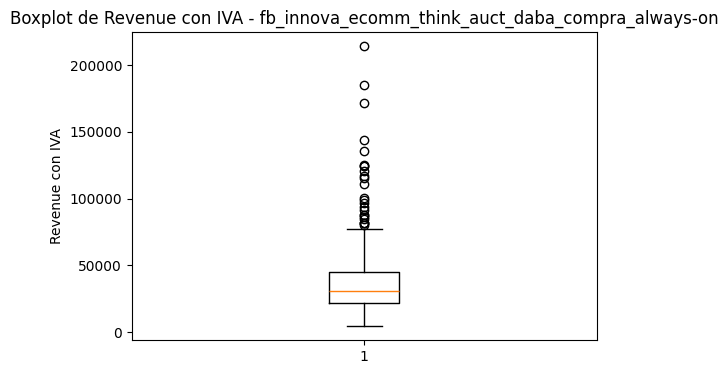

In [ ]:
outliers = boxplot_campana(
    df_all_media,
    campaign_name="fb_innova_ecomm_think_auct_daba_compra_always-on",
    metric="Revenue con IVA"
)

# Histograma

In [ ]:
import matplotlib.pyplot as plt

def histograma_campana(df, campaign_name, metric, bins=30):

    # Filtrar campaña
    df_camp = df[df["campaign.name"] == campaign_name]

    # Verificar datos
    if df_camp.empty:
        print("No hay datos para esa campaña")
        return

    valores = df_camp[metric].dropna()

    # Histograma
    plt.figure(figsize=(7,4))
    plt.hist(valores, bins=bins)

    plt.title(f'Histograma de {metric} - {campaign_name}')
    plt.xlabel(metric)
    plt.ylabel("Frecuencia")
    plt.show()

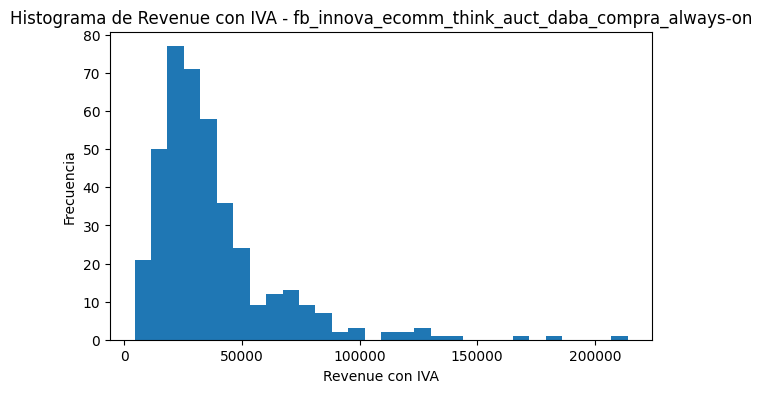

In [ ]:
histograma_campana(df_all_media, "fb_innova_ecomm_think_auct_daba_compra_always-on", "Revenue con IVA")

# Proporción de la inversión

# tomar datos de inversión de la campaña


In [ ]:
#necesito una función a la cual yo le diga quiero la campaña tal, me saque el Revenue con IVA por cada date  y me lo ponga en un dataframe
import pandas as pd

def get_revenue_por_campaña(campaña, df):
    """
    Regresa un dataframe con el Revenue con IVA por fecha
    para la campaña especificada.
    """

    resultado = (
        df[df["campaign.name"] == campaña]   # filtrar campaña
        .groupby("date", as_index=False)["Revenue con IVA"]
        .sum()                              # sumar revenue por día
        .sort_values("date")          # ordenar por fecha
    )

    return resultado

In [ ]:
#para agarrrar spend en vez del revenue
import pandas as pd

def get_spend_por_campaña(campaña, df):
    """
    Regresa un dataframe con el Revenue con IVA por fecha
    para la campaña especificada.
    """

    resultado = (
        df[df["campaign.name"] == campaña]   # filtrar campaña
        .groupby("date", as_index=False)["spend"]
        .sum()                              # sumar revenue por día
        .sort_values("date")          # ordenar por fecha
    )

    return resultado

# Campaña a poner en prophet

In [ ]:

df_prophet = get_revenue_por_campaña(
    "aw_innova_ecomm_do_pla_cat_ao_villanos_hp_nobt_v2",
    df_all_media
)



In [ ]:
df_gasto = get_spend_por_campaña("aw_innova_ecomm_do_pla_cat_ao_villanos_hp_nobt_v2",
    df_all_media
)

In [ ]:
#cambio nombre columna
df_prophet.columns = ['ds', 'y']


# Método más tranquilo

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


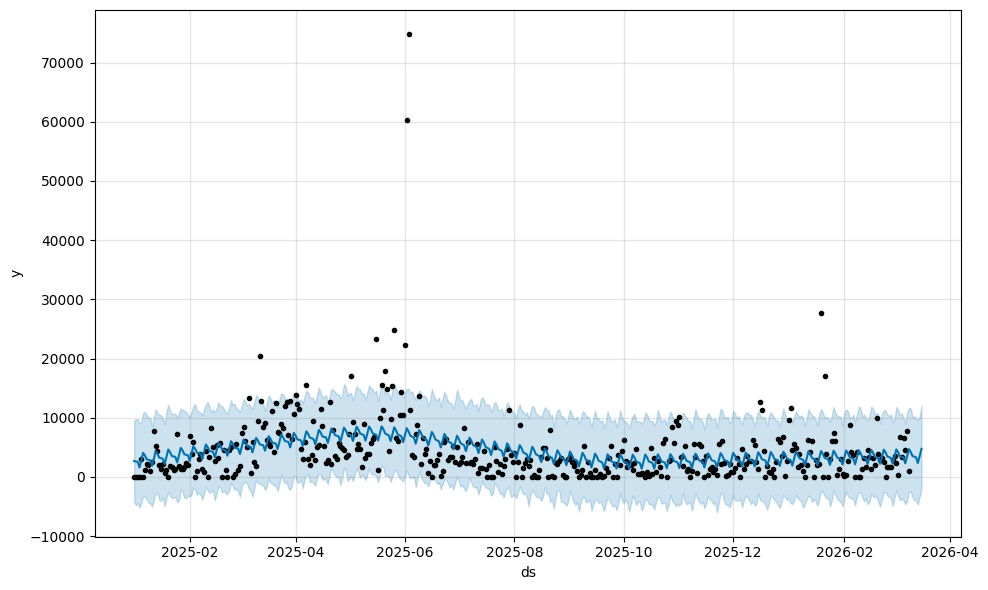

In [ ]:
# Python
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet.loc[(df_prophet['ds'] == '78671.52'), 'y'] = None
model = Prophet().fit(df_prophet)
future = model.make_future_dataframe(periods=7)
fig = model.plot(model.predict(future))

# Forecast con eventos especiales y trend flexible

In [ ]:

hot_sale = pd.DataFrame({
  'holiday': 'hot_sale',
  'ds': pd.to_datetime(['2025-06-03']),
  'lower_window': -2,
  'upper_window': 2,
})
hot_fashion = pd.DataFrame({
  'holiday': 'hot_fashion',
  'ds': pd.to_datetime(['2025-04-02']),
  'lower_window': -2,
  'upper_window': 2,
})
holidays = pd.concat((hot_sale, hot_fashion))

In [ ]:
df_prophet.head()

,ds,y
0,2025-01-01,0.0
1,2025-01-02,0.0
2,2025-01-03,0.0
3,2025-01-04,0.0
4,2025-01-05,3017.0


#Entrenamiento del modelo

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


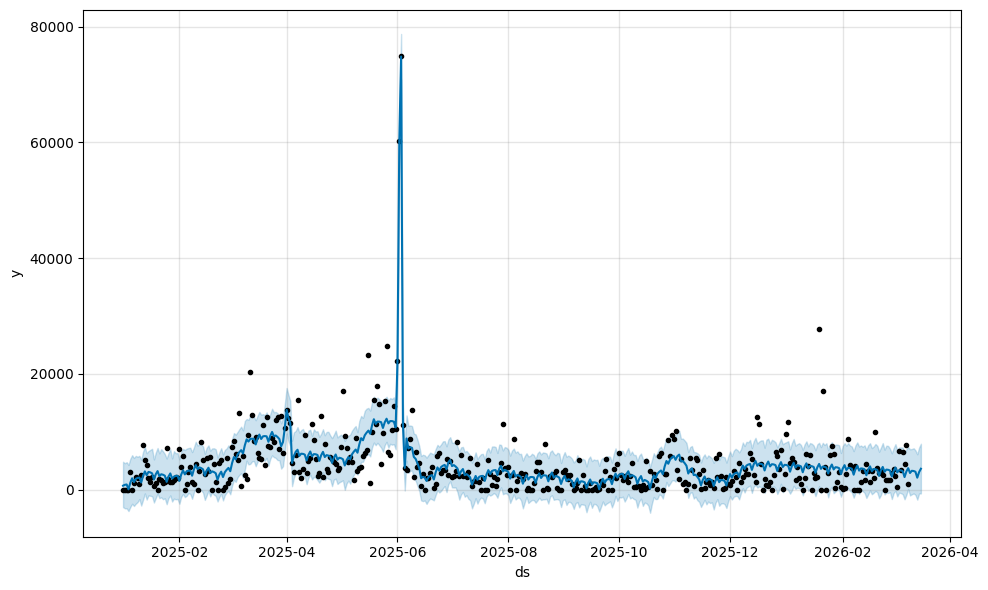

In [ ]:
m = Prophet(changepoint_prior_scale=100, holidays=holidays)
m.fit(df_prophet)
future = m.make_future_dataframe(periods=7)
forecast = m.predict(future)
fig = m.plot(forecast)

In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,hot_sale,hot_sale_lower,hot_sale_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01,491.965284,-3010.846372,4825.258521,491.965284,491.965284,203.520056,203.520056,203.520056,0.0,...,0.0,0.0,0.0,203.520056,203.520056,203.520056,0.0,0.0,0.0,695.485340
1,2025-01-02,661.428594,-3218.384985,4577.495449,661.428594,661.428594,183.096411,183.096411,183.096411,0.0,...,0.0,0.0,0.0,183.096411,183.096411,183.096411,0.0,0.0,0.0,844.525005
2,2025-01-03,830.891904,-3220.719896,4755.168096,830.891904,830.891904,71.355780,71.355780,71.355780,0.0,...,0.0,0.0,0.0,71.355780,71.355780,71.355780,0.0,0.0,0.0,902.247684
3,2025-01-04,1000.355214,-3699.855570,4279.294967,1000.355214,1000.355214,-937.385913,-937.385913,-937.385913,0.0,...,0.0,0.0,0.0,-937.385913,-937.385913,-937.385913,0.0,0.0,0.0,62.969301
4,2025-01-05,1169.818524,-2990.963831,5328.746189,1169.818524,1169.818524,34.334520,34.334520,34.334520,0.0,...,0.0,0.0,0.0,34.334520,34.334520,34.334520,0.0,0.0,0.0,1204.153044


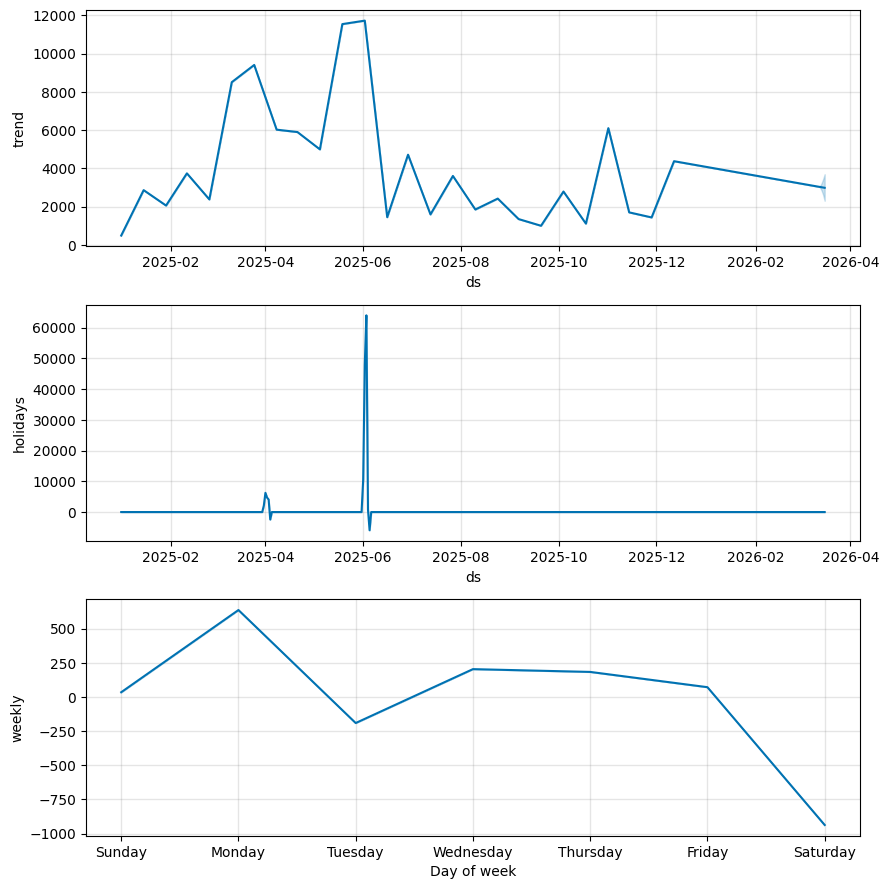

In [ ]:
fig = m.plot_components(forecast)
#el trend nos dice que el revenue de la campaña va a la baja desde enero y que lo más probable es que allí se quede
#entonces toca ir armando el dashboard; primero poner las campañas que vamos a bajar


# Cross Validation


In [ ]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(m, initial='200 days', period='7 days', horizon = '7 days')


INFO:prophet:Making 32 forecasts with cutoffs between 2025-07-23 00:00:00 and 2026-02-25 00:00:00


  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
df_cv.head()


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-07-21,2597.507549,-1324.515445,6671.610029,5114.9,2025-07-20
1,2025-07-22,1070.549324,-2942.242825,5197.018198,2770.1,2025-07-20
2,2025-07-23,1467.133944,-3019.533521,5681.632070,835.2,2025-07-20
3,2025-07-24,1666.784039,-2915.078061,5921.632873,2123.1,2025-07-20
4,2025-07-25,2096.638969,-2365.460056,6353.489942,557.9,2025-07-20


In [ ]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

INFO:prophet:Skipping MAPE because y close to 0


,horizon,mse,rmse,mae,mdape,smape,coverage
0,1 days,2.462669e+07,4962.528727,2876.717778,0.734956,0.804400,0.81250
1,2 days,1.217324e+07,3489.016991,2629.645847,0.809319,0.993053,0.84375
2,3 days,1.429981e+07,3781.509465,2678.265779,0.773908,0.975006,0.84375
3,4 days,8.956630e+06,2992.762871,2289.401921,0.636971,0.829315,0.78125
4,5 days,9.364235e+06,3060.103783,2551.856780,1.474625,1.065683,0.84375


In [ ]:
from prophet.diagnostics import register_performance_metric, rolling_mean_by_h
import numpy as np
@register_performance_metric
def mase(df, w):
    """Mean absolute scale error

        Parameters
        ----------
        df: Cross-validation results dataframe.
        w: Aggregation window size.

        Returns
        -------
        Dataframe with columns horizon and mase.
    """
    e = (df['y'] - df['yhat'])
    d = np.abs(np.diff(df['y'])).sum()/(df['y'].shape[0]-1)
    se = np.abs(e/d)
    if w < 0:
        return pd.DataFrame({'horizon': df['horizon'], 'mase': se})
    return rolling_mean_by_h(
        x=se.values, h=df['horizon'].values, w=w, name='mase'
    )

df_mase = performance_metrics(df_cv, metrics=['mase'])
df_mase.head()

,horizon,mase
0,1 days,0.742143
1,2 days,1.016503
2,3 days,1.009646
3,4 days,0.846602
4,5 days,0.849652



# Gráfica del error

ValueError: Valid values for metrics are: ['mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']

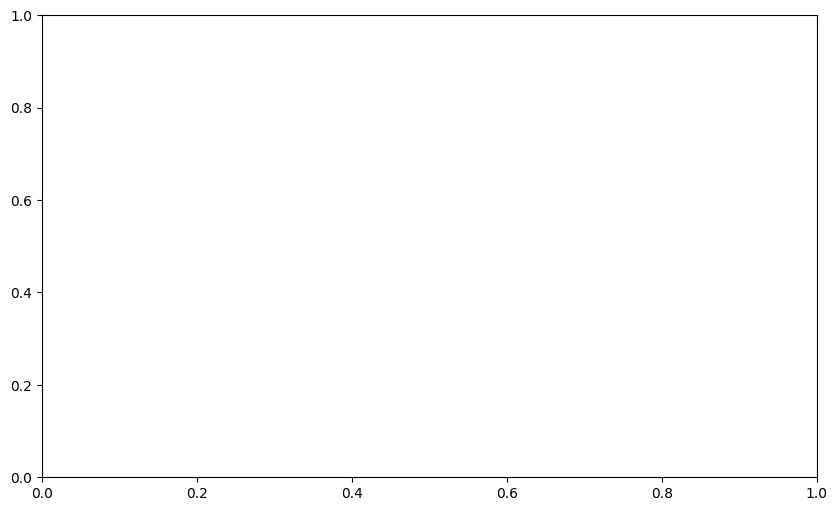

In [ ]:
# Python
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mase')

In [ ]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-07-21,26857.132141,18821.722112,33970.494600,6511.40,2025-07-20
1,2025-07-22,27000.000338,18693.124916,34702.649527,44452.75,2025-07-20
2,2025-07-23,28899.332255,20717.940076,36574.928492,18067.00,2025-07-20
3,2025-07-24,29037.422524,20761.040716,36492.009354,18238.40,2025-07-20
4,2025-07-25,31707.760526,22491.342143,39552.842718,28088.20,2025-07-20
...,...,...,...,...,...,...
219,2026-02-25,18503.465187,8053.614194,29823.025420,19580.60,2026-02-22
220,2026-02-26,18421.857463,8356.175908,28946.635359,17428.64,2026-02-22
221,2026-02-27,18731.610405,7883.977562,30274.848437,9911.80,2026-02-22
222,2026-02-28,16083.016105,4474.363105,27528.568654,11488.20,2026-02-22


# Aplicación de los insights

In [ ]:
#ya tengo el revenue a 7 días predicho más o menos decentemente.
#podemos probar una bajada y una subida al último spend diario que le pusieron estos mequetrefes de 5% en 7 días para ver qué ROAS podemos esperar
def get_spend_por_campaña(campaña, df):
    """
    Regresa un dataframe con el Revenue con IVA por fecha
    para la campaña especificada.
    """

    resultado = (
        df[df["campaign.name"] == campaña]   # filtrar campaña
        .groupby("date", as_index=False)["spend"]
        .sum()                              # sumar revenue por día
        .sort_values("date")          # ordenar por fecha
    )

    return resultado

In [ ]:
#ya tenemos un revenue predicho. Toca ver cuál es
revenue_predicho = forecast[['ds','yhat']].tail(7)

In [ ]:
revenue_predicho.head()

,ds,yhat
433,2026-03-10,2884.342646
434,2026-03-11,3264.165663
435,2026-03-12,3228.966307
436,2026-03-13,3102.449965
437,2026-03-14,2078.932560


In [ ]:
ultimos_dias = revenue_predicho.head(7)
revenue_total = ultimos_dias["yhat"].sum()

In [ ]:
revenue_total

np.float64(21217.659293182543)

In [ ]:
#creo que conviene ver también el spend histórico y por tiempo
#función que me permita saber si la campaña es continua en un rango de tiempo y me regrese un gráfico temporal de su inversión
def analizar_continuidad_campana_gasto(df, campaign_name, fecha_inicio, fecha_fin):

    import pandas as pd
    import matplotlib.pyplot as plt

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    fecha_inicio = pd.to_datetime(fecha_inicio)
    fecha_fin = pd.to_datetime(fecha_fin)

    # Filtrar campaña y periodo
    df_camp = df[
        (df['campaign.name'] == campaign_name) &
        (df['date'] >= fecha_inicio) &
        (df['date'] <= fecha_fin)
    ]

    # Crear rango completo de fechas
    rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

    fechas_existentes = df_camp['date'].dt.normalize().unique()

    fechas_faltantes = sorted(set(rango_completo) - set(fechas_existentes))

    es_continua = len(fechas_faltantes) == 0

    # Agrupar inversión por día (por si hay varias filas por fecha)
    df_plot = df_camp.groupby('date')['spend'].sum().reset_index()

    # Gráfico
    plt.figure()
    plt.plot(df_plot['date'], df_plot['spend'])
    plt.xlabel("Fecha")
    plt.ylabel("Spend")
    plt.title(f"Inversión diaria - {campaign_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return {
        "continua": es_continua,
        "dias_faltantes": fechas_faltantes,
        "dias_con_data": len(fechas_existentes),
        "dias_esperados": len(rango_completo)
    }

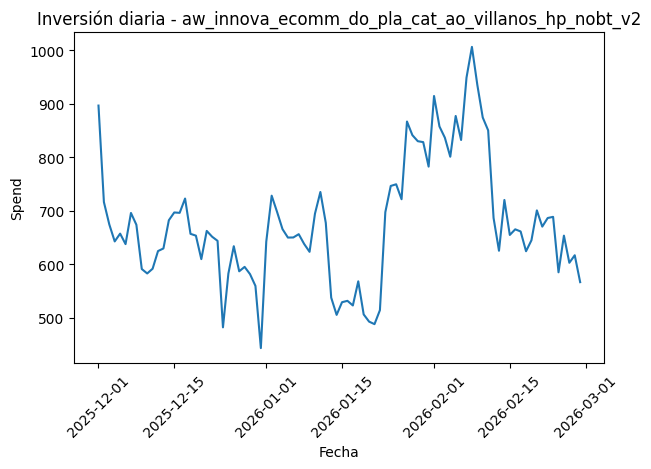

{'continua': True,
 'dias_faltantes': [],
 'dias_con_data': 90,
 'dias_esperados': 90}

In [ ]:
gasto = analizar_continuidad_campana_gasto(
    df_all_media,
    campaign_name="aw_innova_ecomm_do_pla_cat_ao_villanos_hp_nobt_v2",
    fecha_inicio="2025-12-01",
    fecha_fin="2026-02-28"
)

gasto